# Calibration-based cuffless blood pressure estimation

Blood pressure tracking from PPG morphology in the **Pulse Transit Time PPG**
dataset (PhysioNet 1.1.0), with a one-off cuff calibration per subject, evaluated
on every measurement site and wavelength.

**Signals.** Six PPG channels are processed: `pleth_1` to `pleth_6`, covering the
distal and proximal sites at infrared, red and green wavelengths.

**Design.** Each `*_sit.csv` recording is split into a *start* half and an *end*
half. The cuff reading of the start half (`bp_sys_start`, `bp_dia_start`) is given
to the model as the calibration value, and the target is the cuff reading of the
end half. Features are therefore expressed twice: as the end-half value
(`End_*`) and as the change with respect to the calibration half (`Delta_*`).
A subject is kept only when both halves produced valid beats.

When predicting systolic pressure only the systolic calibration value is exposed,
and vice versa for diastolic pressure.

**Validation.** Leave-One-Subject-Out cross-validation, with feature selection
and hyperparameter search performed inside each training fold.

**Before running:** place the dataset CSVs in `data/csv/` as described in
`data/README.md`. The notebook writes its figures and prediction tables to
`results/`.

## Pipeline steps

1. Imports
2. Configuration
3. Signal conditioning
4. Fiducial point detection
5. Derivative landmarks and per-beat summary
6. Feature extraction over the cohort
7. Ensemble feature selection
8. Models, hyperparameter grids and targets
9. Leave-One-Subject-Out evaluation with calibration features
10. Export of the per-subject predictions
11. Results

## Step 1. Imports

`skrebate` supplies ReliefF and `mrmr` supplies the mRMR ranking used by the feature selection ensemble in step 7.

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
import matplotlib.pyplot as plt
import itertools
import neurokit2 as nk
from scipy.signal import find_peaks, butter, sosfiltfilt, detrend, argrelextrema
from scipy.stats import iqr, shapiro, wilcoxon, ttest_rel, pearsonr, rankdata
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    LeaveOneGroupOut,
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.exceptions import ConvergenceWarning

# --- NEW IMPORTS FOR ENSEMBLE FEATURE SELECTION ---
from skrebate import ReliefF
from mrmr import mrmr_regression
import contextlib
import io

## Step 2. Configuration

Sampling rate, bandpass limits, input and output folders, the site and wavelength label of each raw channel, and the short model names used in the exported column headers.

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

fs = 500
lowcut = 0.5
highcut = 10.0
# Folder holding the per-record CSVs and subjects_info.csv (see data/README.md).
base_path = "../data/csv/"

# All generated artefacts (figures, prediction tables) are written here.
results_dir = "../results/"
fig_dir = os.path.join(results_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# --- UPDATED SIGNAL CONFIGURATION ---
signals_config = {
    "pleth_1": {"site": "Distal", "wl": "IR"},
    "pleth_2": {"site": "Distal", "wl": "Red"},
    "pleth_3": {"site": "Distal", "wl": "Green"},
    "pleth_4": {"site": "Proximal", "wl": "IR"},
    "pleth_5": {"site": "Proximal", "wl": "Red"},
    "pleth_6": {"site": "Proximal", "wl": "Green"},
}

model_name_map = {
    "Random Forest": "RandomForest",
    "XGBoost": "XGBoost",
    "SVM (RBF)": "SVM",
    "Gaussian Process": "GaussianProcess",
}

# Global dictionary to store results for the final CSV
final_csv_data = {}

## Step 3. Signal conditioning

Linear detrending followed by a 4th order zero-phase Butterworth bandpass between 0.5 Hz and 10 Hz.

In [ ]:
def process_ppg(data, lowcut, highcut, fs, order=4):
    detrended = detrend(data)
    sos = butter(order, [lowcut, highcut], btype="band", fs=fs, output="sos")
    filtered = sosfiltfilt(sos, detrended)
    return filtered

## Step 4. Fiducial point detection

Per beat the pipeline locates the foot, the systolic peak, the dicrotic notch and
the diastolic peak.

* Beats whose NeuroKit2 template-matching quality score falls below 0.95 are kept
  for heart rate purposes but contribute no morphology features.
* Notch and diastolic peak are chosen as a **pair**: every admissible combination
  inside the beat is scored, and the pair whose timing deviates least from the
  previous accepted beat wins.
* When the main search finds nothing, a relaxed fallback search runs on the same
  beat and is flagged separately.

In [ ]:
def find_ppg_features(signal, peaks_idx, quality_scores, fs):
    foot_points, systolic_peaks, notches, diastolic_peaks = [], [], [], []
    fallback_flags = []  # Track if fallback was used for each beat

    # Pre-calculate velocity (1st derivative) and acceleration (2nd derivative)
    velocity = np.gradient(signal)
    acceleration = np.gradient(velocity)
    abs_acceleration = np.abs(acceleration)

    # 1. Pre-calculate all feet (minimums between consecutive systolic peaks)
    feet = []
    for i in range(len(peaks_idx) - 1):
        start, end = peaks_idx[i], peaks_idx[i + 1]
        f_idx = np.argmin(signal[start:end]) + start
        feet.append(f_idx)

    # --- Tracking variables for the last valid main approach beat ---
    last_main_sys_to_n = None
    last_main_sys_to_d = None
    last_main_n_amp = None  # Track the absolute amplitude of the last main Notch
    last_main_d_amp = None  # Track the absolute amplitude of the last main Diastolic
    penalty_weight = 5.0  # Adjust this to make the penalty more or less aggressive

    # 2. Extract features iteratively based on foot-to-foot beats
    for i in range(len(peaks_idx) - 1):
        sys_idx = peaks_idx[i]
        foot_after = feet[i]

        # ALWAYS record the foot and systolic peak (even for non-quality beats)
        # This allows accurate relative extraction for surrounding beats and HR/HRV analysis
        foot_points.append(foot_after)
        systolic_peaks.append(sys_idx)

        # Quality Check: Discard beat if template match score is < 0.95
        if quality_scores[sys_idx] < 0.95 or np.isnan(quality_scores[sys_idx]):
            notches.append(None)
            diastolic_peaks.append(None)
            fallback_flags.append(False)
            continue

        # Establish the foot-to-foot boundaries for the current beat
        if i > 0 and feet[i - 1] is not None:
            foot_before = feet[i - 1]
        else:
            if len(feet) > 1:
                estimated_beat_len = feet[1] - feet[0]
                foot_before = max(0, foot_after - estimated_beat_len)
            else:
                foot_before = max(0, sys_idx - int(fs * 0.8))

        beat_length = foot_after - foot_before
        s_amp = signal[sys_idx]
        f_amp_beat = signal[foot_before]
        sys_height = s_amp - f_amp_beat

        # 3 & 4. Find Diastolic Peak & Dicrotic Notch (Paired Evaluation) - MAIN APPROACH
        d_search_start = sys_idx + int(0.05 * beat_length)
        d_search_end = min(sys_idx + int(0.75 * beat_length), foot_after)

        d_idx = None
        n_idx = None
        is_fallback = False

        if d_search_start < d_search_end:
            d_segment = signal[d_search_start:d_search_end]
            v_d_segment = velocity[d_search_start:d_search_end]

            # Zero-crossing: First derivative passes from positive (>0) to negative (<=0)
            local_maxima = (
                np.where((v_d_segment[:-1] > 0) & (v_d_segment[1:] <= 0))[0] + 1
            )

            if len(local_maxima) > 0:
                d_floor = f_amp_beat + (0.03 * sys_height)
                d_ceil = f_amp_beat + (0.95 * sys_height)

                valid_d_peaks = [
                    idx for idx in local_maxima if d_floor < d_segment[idx] < d_ceil
                ]

                candidate_pairs = []

                # Evaluate all valid Diastolic candidates
                for d_cand_rel in valid_d_peaks:
                    candidate_d_idx = d_search_start + d_cand_rel

                    # For each Diastolic candidate, find preceding Notch candidates
                    n_search_start = sys_idx + int(0.05 * beat_length)
                    n_search_end = candidate_d_idx

                    if n_search_start < n_search_end:
                        n_segment = signal[n_search_start:n_search_end]
                        v_n_segment = velocity[n_search_start:n_search_end]

                        # Zero-crossing: First derivative passes from negative (<0) to positive (>=0)
                        local_minima = (
                            np.where((v_n_segment[:-1] < 0) & (v_n_segment[1:] >= 0))[0]
                            + 1
                        )

                        height_floor = f_amp_beat + (0.10 * sys_height)
                        height_ceiling = f_amp_beat + (0.92 * sys_height)

                        valid_notches = [
                            idx
                            for idx in local_minima
                            if height_floor < n_segment[idx] < height_ceiling
                        ]

                        for n_cand_rel in valid_notches:
                            candidate_n_idx = n_search_start + n_cand_rel

                            d_amp = signal[candidate_d_idx]
                            n_amp = signal[candidate_n_idx]
                            diff = d_amp - n_amp

                            # Keep pair if it meets baseline sanity check
                            if diff >= -0.9:
                                # Penalty Calculation for MAIN APPROACH
                                penalty = 0.0
                                if (
                                    last_main_sys_to_n is not None
                                    and last_main_sys_to_d is not None
                                ):
                                    cand_sys_to_n = candidate_n_idx - sys_idx
                                    cand_sys_to_d = candidate_d_idx - sys_idx

                                    dev_n_sec = (
                                        abs(cand_sys_to_n - last_main_sys_to_n) / fs
                                    )
                                    dev_d_sec = (
                                        abs(cand_sys_to_d - last_main_sys_to_d) / fs
                                    )

                                    penalty = penalty_weight * (dev_n_sec + dev_d_sec)

                                # Shift diff by +1.0 to ensure a positive numerator
                                main_score = (diff + 1.0) / (1.0 + penalty)

                                candidate_pairs.append(
                                    {
                                        "d_idx": candidate_d_idx,
                                        "n_idx": candidate_n_idx,
                                        "d_amp": d_amp,
                                        "n_amp": n_amp,
                                        "diff": diff,
                                        "score": main_score,
                                    }
                                )

                if candidate_pairs:
                    # Sort pairs descending by the penalized score
                    candidate_pairs.sort(key=lambda x: x["score"], reverse=True)

                    if len(candidate_pairs) == 1:
                        best_pair = candidate_pairs[0]
                    else:
                        score_1st = candidate_pairs[0]["score"]
                        score_2nd = candidate_pairs[1]["score"]

                        # If the top two penalized scores are extremely close (ambiguous)
                        if (score_1st - score_2nd) < 0.05:
                            # Pick the pair where the NOTCH is closest to half amplitude
                            half_amp_target = f_amp_beat + 0.66 * sys_height
                            best_pair = min(
                                candidate_pairs,
                                key=lambda x: abs(x["n_amp"] - half_amp_target),
                            )
                        else:
                            best_pair = candidate_pairs[0]

                    d_idx = best_pair["d_idx"]
                    n_idx = best_pair["n_idx"]

                    # Check Absolute Amplitude difference with previous main pair
                    if last_main_n_amp is not None and last_main_d_amp is not None:
                        # If the absolute amplitude of the pair shifted by 1.0 or more, force fallback
                        if (
                            abs(best_pair["n_amp"] - last_main_n_amp) >= 1.0
                            or abs(best_pair["d_amp"] - last_main_d_amp) >= 1.0
                        ):
                            d_idx = None
                            n_idx = None

        # 5. --- DERIVATIVE FALLBACK MECHANISM ---
        if d_idx is None or n_idx is None:
            velocity_fb = np.gradient(signal)
            abs_v = np.abs(velocity_fb)

            fb_search_start = sys_idx + int(0.05 * beat_length)
            fb_search_end = min(sys_idx + int(0.75 * beat_length), foot_after)

            if fb_search_start < fb_search_end:
                abs_v_segment = abs_v[fb_search_start:fb_search_end]

                # Calculate the mean absolute speed in this descending slope interval
                mean_abs_v = np.mean(abs_v_segment)

                # Notch candidate: absolute speed drops to <= 0.35x mean descending speed
                n_cands = np.where(abs_v_segment <= 0.35 * mean_abs_v)[0]

                # Diastolic candidate: absolute speed rises to >= 0.40x mean descending speed
                d_cands = np.where(abs_v_segment >= 0.40 * mean_abs_v)[0]

                candidate_pairs_fb = []

                for n_cand in n_cands:
                    for d_cand in d_cands:
                        # Ensure the diastolic peak occurs chronologically AFTER the notch
                        if d_cand > n_cand:
                            candidate_n_idx = fb_search_start + n_cand
                            candidate_d_idx = fb_search_start + d_cand

                            n_amp = signal[candidate_n_idx]
                            d_amp = signal[candidate_d_idx]

                            n_speed = abs_v_segment[n_cand]
                            d_speed = abs_v_segment[d_cand]
                            speed_diff = abs(d_speed - n_speed)

                            # Calculate the difference in absolute second derivative for fallback
                            acc_diff_fb = abs(
                                abs_acceleration[candidate_d_idx]
                                - abs_acceleration[candidate_n_idx]
                            )

                            # --- SANITY CHECKS ---
                            # 1. Ensure it forms a plateau/shelf
                            is_shelf_like = abs(n_amp - d_amp) < (0.15 * sys_height)

                            # 2. Ensure if diastolic peak is lower, it is maximum 0.1 lower
                            valid_drop = (
                                (n_amp - d_amp <= 0.1) if (n_amp > d_amp) else True
                            )

                            # 3. Amplitude restrictions
                            if (
                                (n_amp > f_amp_beat + 0.20 * sys_height)
                                and (d_amp > f_amp_beat + 0.20 * sys_height)
                                and (n_amp < f_amp_beat + 0.85 * sys_height)
                                and is_shelf_like
                                and valid_drop
                            ):
                                # Penalty Calculation based on distance to last Main Approach
                                penalty = 0.0
                                if (
                                    last_main_sys_to_n is not None
                                    and last_main_sys_to_d is not None
                                ):
                                    cand_sys_to_n = candidate_n_idx - sys_idx
                                    cand_sys_to_d = candidate_d_idx - sys_idx

                                    # Convert sample deviation to seconds
                                    dev_n_sec = (
                                        abs(cand_sys_to_n - last_main_sys_to_n) / fs
                                    )
                                    dev_d_sec = (
                                        abs(cand_sys_to_d - last_main_sys_to_d) / fs
                                    )

                                    penalty = penalty_weight * (dev_n_sec + dev_d_sec)

                                # Final score: acc_diff heavily penalized if the pair is temporally far
                                final_score = acc_diff_fb / (1.0 + penalty)

                                candidate_pairs_fb.append(
                                    {
                                        "n_idx": candidate_n_idx,
                                        "d_idx": candidate_d_idx,
                                        "n_amp": n_amp,
                                        "d_amp": d_amp,
                                        "speed_diff": speed_diff,
                                        "acc_diff": acc_diff_fb,
                                        "score": final_score,
                                    }
                                )

                if candidate_pairs_fb:
                    # Grab the pair with the HIGHEST penalized score
                    best_fb_pair = max(
                        candidate_pairs_fb,
                        key=lambda x: x["score"],
                    )
                    n_idx = best_fb_pair["n_idx"]
                    d_idx = best_fb_pair["d_idx"]
                    is_fallback = True

        # Update the tracking variables IF the pair was found via the main approach
        if not is_fallback and n_idx is not None and d_idx is not None:
            last_main_sys_to_n = n_idx - sys_idx
            last_main_sys_to_d = d_idx - sys_idx
            last_main_n_amp = signal[n_idx]  # Track absolute notch amplitude
            last_main_d_amp = signal[d_idx]  # Track absolute diastolic amplitude

        notches.append(n_idx)
        diastolic_peaks.append(d_idx)
        fallback_flags.append(is_fallback)

    return foot_points, systolic_peaks, notches, diastolic_peaks, fallback_flags

## Step 5. Derivative landmarks and per-beat summary

`find_slope_features` returns the indices of maximum ascending and maximum descending slope. `get_stats` reduces a per-beat feature vector to its median, which is robust to the residual outlier beats.

In [ ]:
def find_slope_features(signal, f_pts, s_pts, n_pts, fs):
    m_asc_idx, m_desc_idx = [], []
    velocity = np.diff(signal) * fs
    for i in range(len(f_pts) - 1):
        f, s_next, n_next = f_pts[i], s_pts[i + 1], n_pts[i + 1]
        if all(x is not None for x in [f, s_next, n_next]):
            m_asc_idx.append(np.argmax(velocity[f:s_next]) + f)
            m_desc_idx.append(np.argmin(velocity[s_next:n_next]) + s_next)
        else:
            m_asc_idx.append(None)
            m_desc_idx.append(None)
    m_asc_idx.append(None)
    m_desc_idx.append(None)
    return m_asc_idx, m_desc_idx


def get_stats(data):
    clean_data = [x for x in data if not np.isnan(x)]
    if not clean_data:
        return [np.nan]
    return [np.median(clean_data)]

## Step 6. Feature extraction over the cohort

For every subject, every channel and every half recording the loop builds 21
morphological features (amplitudes, relative timings, amplitude ratios, first and
second derivative extrema and their timings, systolic upstroke times at 25%, 50%
and 75% of the beat amplitude), takes their median, and appends mean heart rate
and heart rate variability.

A half recording is discarded when it yields fewer than 5 fully valid beats. The
per-half dictionaries are kept separately so that step 9 can form the `Delta_*`
and `End_*` pairs.

In [1]:
subjects_info_path = os.path.join(base_path, "subjects_info.csv")
info_df = (
    pd.read_csv(subjects_info_path) if os.path.exists(subjects_info_path) else None
)

user_detailed_stats = {wl_col: {} for wl_col in signals_config.keys()}
discarded_users = {wl_col: [] for wl_col in signals_config.keys()}
files = sorted(glob.glob(os.path.join(base_path, "*_sit.csv")))

print(
    "Extracting features for all wavelengths and sites (Splitting into Start & End halves)..."
)
for file_path in files:
    uid = os.path.basename(file_path).split("_")[0]
    try:
        df = pd.read_csv(file_path)
        mid_idx = len(df) // 2
        halves = {"start": df.iloc[:mid_idx].copy(), "end": df.iloc[mid_idx:].copy()}

        for wl_col in signals_config.keys():
            if wl_col not in df.columns:
                discarded_users[wl_col].append(f"{uid} (Missing Col)")
                continue

            if uid not in user_detailed_stats[wl_col]:
                user_detailed_stats[wl_col][uid] = {}

            for half_name, half_df in halves.items():
                data_arr = half_df[wl_col].values
                if len(data_arr) == 0:
                    continue

                clean = -process_ppg(data_arr, lowcut, highcut, fs)
                clean = (clean - np.mean(clean)) / np.std(clean)
                peaks, _ = find_peaks(clean, distance=int(fs * 0.35), height=0.20)

                if len(peaks) < 2:
                    valid_data = []
                else:
                    quality_scores = nk.ppg_quality(
                        clean, peaks=peaks, sampling_rate=fs, method="templatematch"
                    )
                    f, s, n, d, _ = find_ppg_features(clean, peaks, quality_scores, fs)
                    v_asc, v_desc = find_slope_features(clean, f, s, n, fs)

                    velocity = np.diff(clean) * fs
                    acceleration = np.diff(velocity) * fs

                    valid_data = []
                    for i in range(len(f) - 1):
                        if (
                            all(x[i + 1] is not None for x in [s, n, d])
                            and v_asc[i] is not None
                            and v_desc[i] is not None
                            and f[i] is not None
                        ):
                            curr_f, curr_s, curr_n, curr_d = (
                                f[i],
                                s[i + 1],
                                n[i + 1],
                                d[i + 1],
                            )
                            next_f = f[i + 1]
                            v_max, v_min = v_asc[i], v_desc[i]

                            accel_seg = acceleration[
                                curr_f : min(next_f, len(acceleration))
                            ]

                            if len(accel_seg) > 0:
                                a_max = np.max(accel_seg)
                                a_min = np.min(accel_seg)
                                t_amax = np.argmax(accel_seg) / fs
                                t_amin = np.argmin(accel_seg) / fs
                            else:
                                a_max, a_min, t_amax, t_amin = (
                                    np.nan,
                                    np.nan,
                                    np.nan,
                                    np.nan,
                                )

                            t_vmax = (v_max - curr_f) / fs
                            t_vmin = (v_min - curr_f) / fs
                            amp_f, amp_s = clean[curr_f], clean[curr_s]
                            amp_diff = amp_s - amp_f

                            t_25, t_50, t_75 = np.nan, np.nan, np.nan
                            if curr_s > curr_f and amp_diff > 0:
                                segment = clean[curr_f:curr_s]
                                t_25 = (
                                    np.argmax(segment >= amp_f + 0.25 * amp_diff)
                                    + curr_f
                                    - curr_f
                                ) / fs
                                t_50 = (
                                    np.argmax(segment >= amp_f + 0.50 * amp_diff)
                                    + curr_f
                                    - curr_f
                                ) / fs
                                t_75 = (
                                    np.argmax(segment >= amp_f + 0.75 * amp_diff)
                                    + curr_f
                                    - curr_f
                                ) / fs

                            valid_data.append(
                                {
                                    "S_amp": clean[curr_s],
                                    "D_amp": clean[curr_d],
                                    "N_amp": clean[curr_n],
                                    "T_S_rel_F": (curr_s - curr_f) / fs,
                                    "T_N_rel_S": (curr_n - curr_s) / fs,
                                    "T_D_rel_S": (curr_d - curr_s) / fs,
                                    "T_D_rel_N": (curr_d - curr_n) / fs,
                                    "Ratio_S_D": clean[curr_s] / clean[curr_d],
                                    "Ratio_N_D": clean[curr_n] / clean[curr_d],
                                    "Ratio_S_N": clean[curr_s] / clean[curr_n],
                                    "Vmax": velocity[v_max],
                                    "Vmin": velocity[v_min],
                                    "Amax": a_max,
                                    "Amin": a_min,
                                    "T_Vmax": t_vmax,
                                    "T_Vmin": t_vmin,
                                    "T_Amax": t_amax,
                                    "T_Amin": t_amin,
                                    "T_Amp_25": t_25,
                                    "T_Amp_50": t_50,
                                    "T_Amp_75": t_75,
                                }
                            )

                    if len(valid_data) >= 5:
                        vdf = pd.DataFrame(valid_data)
                        stats_dict = {}
                        for col in vdf.columns:
                            stats_dict[col] = get_stats(vdf[col].tolist())[0]

                        valid_s_peaks = [p for p in s if p is not None]
                        if len(valid_s_peaks) > 1:
                            ppi = np.diff(valid_s_peaks) / fs
                            valid_ppi = ppi[(ppi > 0.3) & (ppi < 2.0)]
                            if len(valid_ppi) > 0:
                                hr_array = 60.0 / valid_ppi
                                stats_dict["Mean_HR"] = np.mean(hr_array)
                                stats_dict["HRV"] = np.std(hr_array)
                            else:
                                stats_dict["Mean_HR"], stats_dict["HRV"] = (
                                    np.nan,
                                    np.nan,
                                )
                        else:
                            stats_dict["Mean_HR"], stats_dict["HRV"] = np.nan, np.nan

                        user_detailed_stats[wl_col][uid][half_name] = stats_dict
                    else:
                        discarded_users[wl_col].append(f"{uid}_{half_name}")

    except Exception as e:
        print(f"Error processing user {uid}: {e}")


# --- ENSEMBLE FEATURE SELECTION HELPER ---

Extracting features for all wavelengths and sites (Splitting into Start & End halves)...

## Step 7. Ensemble feature selection

Four independent rankings are computed on the training fold only and combined by
Borda count, that is by averaging the ranks:

1. absolute Pearson correlation with the target
2. recursive feature elimination
3. ReliefF
4. mRMR

In [ ]:
def ensemble_feature_selection(X, y, estimator):
    """
    Ranks features using 4 different methods, averages their ranks (voting),
    and returns ALL features sorted by their combined ensemble rank.
    """
    # 1. Pearson Correlation
    corrs = np.abs([pearsonr(X.iloc[:, i], y)[0] for i in range(X.shape[1])])
    corrs[np.isnan(corrs)] = 0
    corr_ranks = rankdata(-corrs)  # Descending, highest absolute corr gets rank 1

    # 2. RFE
    rfe = RFE(estimator=estimator, n_features_to_select=1)  # Set to 1 to rank all
    rfe.fit(X, y)
    rfe_ranks = rfe.ranking_

    # 3. ReliefF
    relief = ReliefF(n_features_to_select=X.shape[1], n_neighbors=20, n_jobs=-1)
    relief.fit(X.values, y.values)
    relief_ranks = rankdata(-relief.feature_importances_)

    # 4. mRMR (Suppress output to keep console clean)
    with contextlib.redirect_stdout(io.StringIO()):
        mrmr_selected = mrmr_regression(X=X, y=y, K=X.shape[1], show_progress=False)

    mrmr_ranks = np.zeros(X.shape[1])
    for i, col in enumerate(X.columns):
        mrmr_ranks[i] = mrmr_selected.index(col) + 1

    # Average ranks (Voting Strategy: Borda Count)
    avg_ranks = (corr_ranks + rfe_ranks + relief_ranks + mrmr_ranks) / 4.0
    final_ranks = rankdata(avg_ranks)

    # Sort ALL features by rank (ascending: 1 is best)
    selected_indices = np.argsort(final_ranks)
    sorted_features = X.columns[selected_indices].tolist()

    return sorted_features, final_ranks

## Step 8. Models, hyperparameter grids and targets

Four regressors are compared: Random Forest, XGBoost, SVM with an RBF kernel and a Gaussian Process. Each has its own grid, searched by 3-fold inner cross-validation on mean absolute error.

In [ ]:
targets = {"Systolic BP": "GT_sys_end", "Diastolic BP": "GT_dia_end"}
all_results = {}

param_grids = {
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5, 7],
    },
    "SVM (RBF)": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto", 0.1, 0.01],
        "epsilon": [0.01, 0.1, 0.2],
    },
    "Gaussian Process": {
        "alpha": [1e-3, 1e-2, 0.1, 1.0],
        "normalize_y": [True, False],
        "n_restarts_optimizer": [0, 2],
    },
}

features_printed = False

## Step 9. Leave-One-Subject-Out evaluation with calibration features

The feature table is assembled per subject: demographics, the matching cuff
calibration value, and for every PPG metric both the end-half value and its
change relative to the calibration half.

For each channel and each target the outer loop holds out one subject at a time.
Inside every training fold the pipeline scales the features, ranks them with the
step 7 ensemble, then jointly searches over the number of retained features
(5, 10, 15, 20, 25) and the model hyperparameters.

Reported per model: MAE, mean error (bias) and standard deviation of the error.
Shapiro-Wilk tests the normality of the absolute error vectors, and the pairwise
model comparison uses a paired t-test when both error vectors are normal and the
Wilcoxon signed-rank test otherwise. A Bland-Altman plot is produced for the
best systolic model of each channel.




################################################################################
### EVALUATING: Distal IR (pleth_1) ###
Discarded blocks (< 5 valid beats): s15_start, s15_end, s4_end, s9_start, s9_end
################################################################################

--- EXTRACTED CALIBRATION FEATURES (Total: 52) ---

--- Predicting Systolic BP using Distal IR PPG (LOSO CV) ---
Model                | MAE        | ME         | Std Error 
------------------------------------------------------------
Random Forest        | 4.71       | -0.70      | 7.05      
XGBoost              | 4.27       | -1.64      | 5.45      
SVM (RBF)            | 6.72       | -0.28      | 9.25      
Gaussian Process     | 7.13       | -1.15      | 9.94      

>>> BEST MODEL for Systolic BP: XGBoost (Overall MAE: 4.27) <<<
>>> Top 10 Most Significant Features (based on average Ensemble rank):
    1. Calib_sys                 (Avg Rank: 1.00)
    2. End_T_S_rel_F             (Avg Rank: 2.82)
   

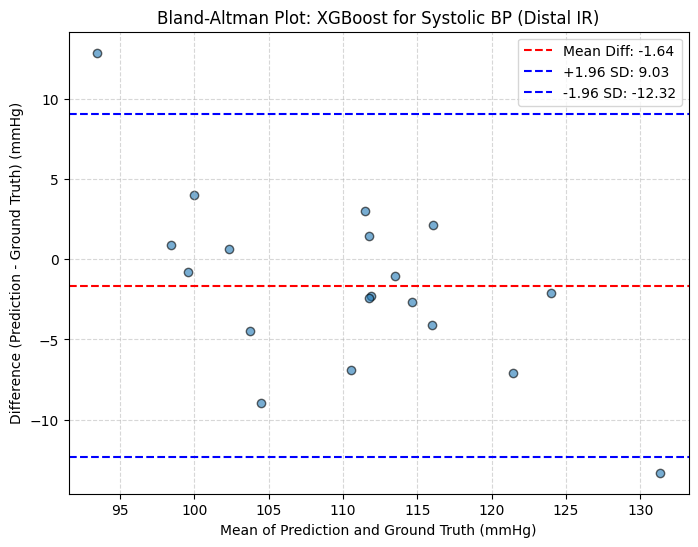


--- Statistical Comparison of Models for Systolic BP (Distal IR) ---
Shapiro-Wilk for Random Forest       : p-value = 3.2259e-04 (Non-Normal)
Shapiro-Wilk for XGBoost             : p-value = 2.0007e-03 (Non-Normal)
Shapiro-Wilk for SVM (RBF)           : p-value = 5.7538e-03 (Non-Normal)
Shapiro-Wilk for Gaussian Process    : p-value = 5.4984e-03 (Non-Normal)

Pairwise Comparisons (alpha = 0.05):
  Random Forest vs XGBoost         | Test: Wilcoxon Signed-Rank | p-value = 6.2256e-01 | Not Significant
  Random Forest vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 8.7429e-02 | Not Significant
  Random Forest vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 6.0207e-02 | Not Significant
        XGBoost vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 3.2341e-02 | Significant
        XGBoost vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 6.6288e-02 | Not Significant
      SVM (RBF) vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 5.1

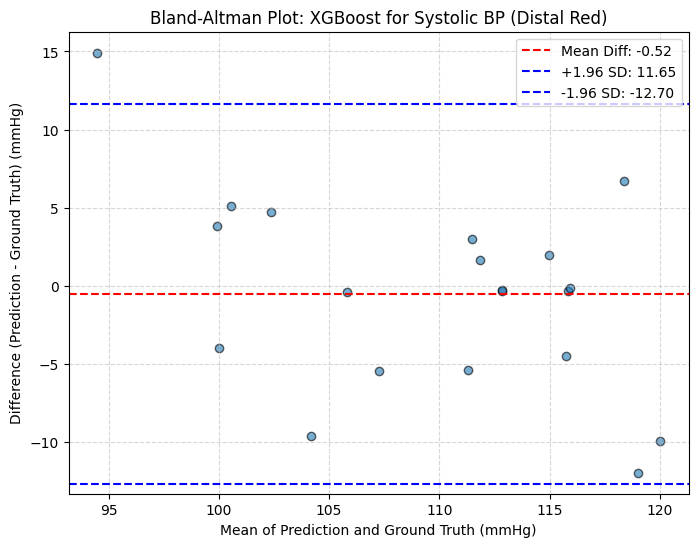


--- Statistical Comparison of Models for Systolic BP (Distal Red) ---
Shapiro-Wilk for Random Forest       : p-value = 9.2431e-03 (Non-Normal)
Shapiro-Wilk for XGBoost             : p-value = 3.5320e-02 (Non-Normal)
Shapiro-Wilk for SVM (RBF)           : p-value = 8.3863e-03 (Non-Normal)
Shapiro-Wilk for Gaussian Process    : p-value = 9.7423e-04 (Non-Normal)

Pairwise Comparisons (alpha = 0.05):
  Random Forest vs XGBoost         | Test: Wilcoxon Signed-Rank | p-value = 4.3043e-01 | Not Significant
  Random Forest vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 4.5238e-01 | Not Significant
  Random Forest vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 3.4881e-01 | Not Significant
        XGBoost vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 4.5238e-01 | Not Significant
        XGBoost vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 4.7491e-01 | Not Significant
      SVM (RBF) vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value 

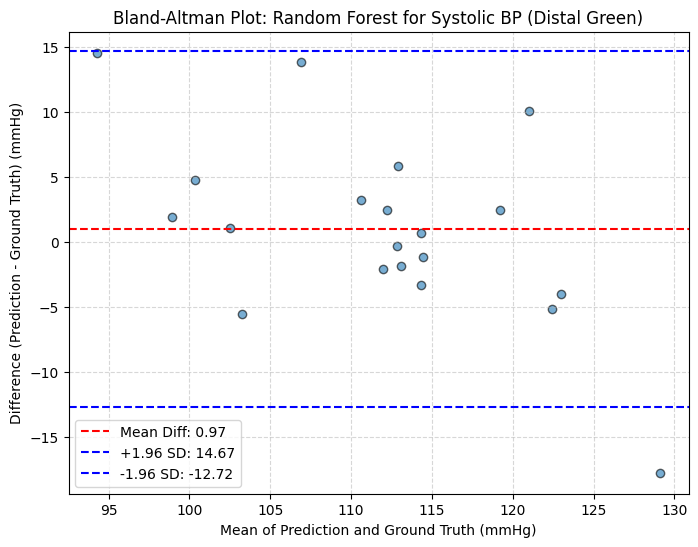


--- Statistical Comparison of Models for Systolic BP (Distal Green) ---
Shapiro-Wilk for Random Forest       : p-value = 8.0308e-04 (Non-Normal)
Shapiro-Wilk for XGBoost             : p-value = 9.6442e-03 (Non-Normal)
Shapiro-Wilk for SVM (RBF)           : p-value = 9.4722e-04 (Non-Normal)
Shapiro-Wilk for Gaussian Process    : p-value = 8.2706e-03 (Non-Normal)

Pairwise Comparisons (alpha = 0.05):
  Random Forest vs XGBoost         | Test: Wilcoxon Signed-Rank | p-value = 7.0118e-01 | Not Significant
  Random Forest vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 2.9575e-02 | Significant
  Random Forest vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 2.6642e-02 | Significant
        XGBoost vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 2.3051e-01 | Not Significant
        XGBoost vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 7.5851e-02 | Not Significant
      SVM (RBF) vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 1.64

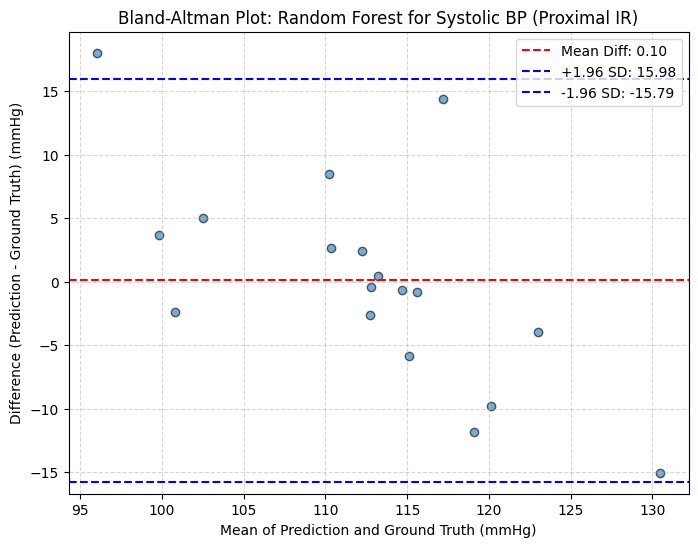


--- Statistical Comparison of Models for Systolic BP (Proximal IR) ---
Shapiro-Wilk for Random Forest       : p-value = 1.5283e-02 (Non-Normal)
Shapiro-Wilk for XGBoost             : p-value = 2.7184e-03 (Non-Normal)
Shapiro-Wilk for SVM (RBF)           : p-value = 2.5570e-02 (Non-Normal)
Shapiro-Wilk for Gaussian Process    : p-value = 2.1537e-03 (Non-Normal)

Pairwise Comparisons (alpha = 0.05):
  Random Forest vs XGBoost         | Test: Wilcoxon Signed-Rank | p-value = 4.8279e-02 | Significant
  Random Forest vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 4.3167e-02 | Significant
  Random Forest vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 1.3870e-02 | Significant
        XGBoost vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 5.7984e-01 | Not Significant
        XGBoost vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 4.9508e-01 | Not Significant
      SVM (RBF) vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 1.9639e-0

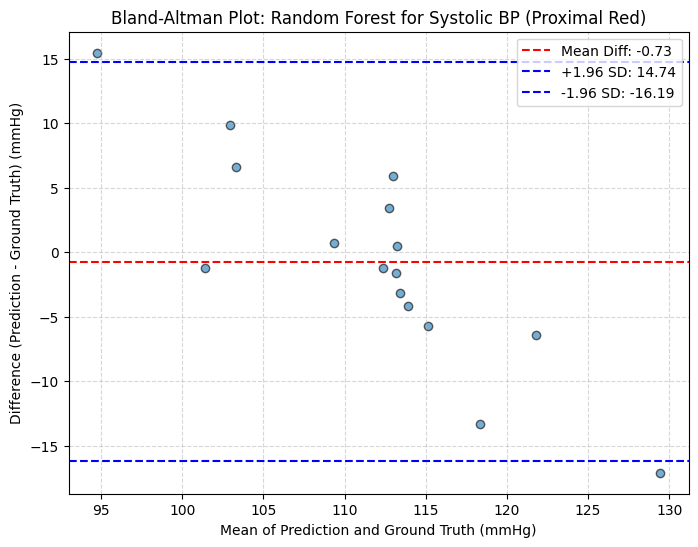


--- Statistical Comparison of Models for Systolic BP (Proximal Red) ---
Shapiro-Wilk for Random Forest       : p-value = 2.9910e-02 (Non-Normal)
Shapiro-Wilk for XGBoost             : p-value = 2.8442e-02 (Non-Normal)
Shapiro-Wilk for SVM (RBF)           : p-value = 1.8632e-03 (Non-Normal)
Shapiro-Wilk for Gaussian Process    : p-value = 3.1331e-03 (Non-Normal)

Pairwise Comparisons (alpha = 0.05):
  Random Forest vs XGBoost         | Test: Wilcoxon Signed-Rank | p-value = 8.9993e-01 | Not Significant
  Random Forest vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 8.3252e-02 | Not Significant
  Random Forest vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 1.0458e-01 | Not Significant
        XGBoost vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 7.8195e-01 | Not Significant
        XGBoost vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 6.6855e-01 | Not Significant
      SVM (RBF) vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-valu

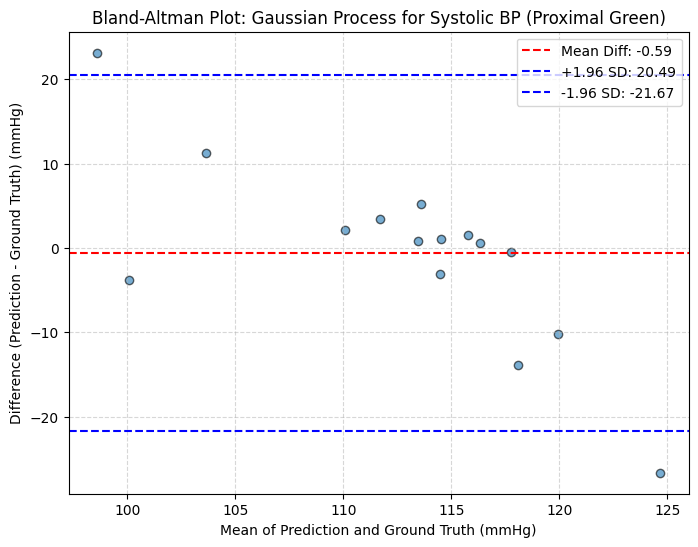


--- Statistical Comparison of Models for Systolic BP (Proximal Green) ---
Shapiro-Wilk for Random Forest       : p-value = 1.6232e-03 (Non-Normal)
Shapiro-Wilk for XGBoost             : p-value = 1.2417e-01 (Normal)
Shapiro-Wilk for SVM (RBF)           : p-value = 5.9715e-04 (Non-Normal)
Shapiro-Wilk for Gaussian Process    : p-value = 2.0619e-03 (Non-Normal)

Pairwise Comparisons (alpha = 0.05):
  Random Forest vs XGBoost         | Test: Wilcoxon Signed-Rank | p-value = 8.0396e-01 | Not Significant
  Random Forest vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 1.0000e+00 | Not Significant
  Random Forest vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 5.6140e-01 | Not Significant
        XGBoost vs SVM (RBF)       | Test: Wilcoxon Signed-Rank | p-value = 8.4692e-01 | Not Significant
        XGBoost vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value = 5.6140e-01 | Not Significant
      SVM (RBF) vs Gaussian Proces | Test: Wilcoxon Signed-Rank | p-value 

In [2]:
for wl_col, config_info in signals_config.items():
    site = config_info["site"]
    wl_name = config_info["wl"]
    display_name = f"{site} {wl_name}"

    print(f"\n\n{'#'*80}")
    print(f"### EVALUATING: {display_name} ({wl_col}) ###")

    discard_list = discarded_users[wl_col]
    print(
        f"Discarded blocks (< 5 valid beats): {', '.join(discard_list) if discard_list else 'None'}"
    )
    print(f"{'#'*80}")

    data_rows = []
    if info_df is not None:
        for uid, user_halves in user_detailed_stats[wl_col].items():
            record_name = f"{uid}_sit"
            user_info = info_df[info_df["record"] == record_name]

            # CRITICAL CHECK: Ensure BOTH "start" and "end" halves are present and valid.
            if not user_info.empty and "start" in user_halves and "end" in user_halves:
                try:
                    user_features = {"uid": uid}

                    user_features["age"] = float(user_info["age"].values[0])
                    user_features["height"] = float(user_info["height"].values[0])
                    user_features["weight"] = float(user_info["weight"].values[0])
                    gender_str = str(user_info["gender"].values[0]).strip().lower()
                    user_features["gender"] = 1 if gender_str.startswith("m") else 0

                    user_features["Calib_sys"] = float(
                        user_info["bp_sys_start"].values[0]
                    )
                    user_features["Calib_dia"] = float(
                        user_info["bp_dia_start"].values[0]
                    )

                    user_features["GT_sys_end"] = float(
                        user_info["bp_sys_end"].values[0]
                    )
                    user_features["GT_dia_end"] = float(
                        user_info["bp_dia_end"].values[0]
                    )

                    stats_start = user_halves["start"]
                    stats_end = user_halves["end"]

                    for metric in stats_start.keys():
                        if metric in stats_end:
                            delta_val = stats_end[metric] - stats_start[metric]
                            user_features[f"Delta_{metric}"] = delta_val
                            user_features[f"End_{metric}"] = stats_end[metric]

                    data_rows.append(user_features)
                except Exception as e:
                    pass

    final_df = pd.DataFrame(data_rows)

    if final_df.empty:
        print(f"No valid data extracted for {display_name}. Skipping...")
        continue

    final_df = final_df.dropna(subset=["GT_sys_end", "GT_dia_end"])
    numeric_cols = final_df.select_dtypes(include=[np.number]).columns
    final_df[numeric_cols] = final_df[numeric_cols].fillna(
        final_df[numeric_cols].mean()
    )

    all_results[display_name] = {}

    if not features_printed:
        X_full = final_df.drop(columns=["GT_sys_end", "GT_dia_end", "uid"])
        print(
            f"\n--- EXTRACTED CALIBRATION FEATURES (Total: {len(X_full.columns)}) ---"
        )
        features_printed = True

    for target_name, target_col in targets.items():
        print(f"\n--- Predicting {target_name} using {display_name} PPG (LOSO CV) ---")

        groups = final_df["uid"]

        if target_col == "GT_sys_end":
            X = final_df.drop(columns=["GT_sys_end", "GT_dia_end", "uid", "Calib_dia"])
            target_short = "S"
        else:
            X = final_df.drop(columns=["GT_sys_end", "GT_dia_end", "uid", "Calib_sys"])
            target_short = "D"

        y = final_df[target_col]

        logo = LeaveOneGroupOut()
        models = {
            "Random Forest": RandomForestRegressor(random_state=42),
            "XGBoost": XGBRegressor(random_state=42),
            "SVM (RBF)": SVR(),
            "Gaussian Process": GaussianProcessRegressor(random_state=42),
        }

        results = []
        model_feature_ranks = {name: np.zeros(X.shape[1]) for name in models.keys()}

        print(f"{'Model':<20} | {'MAE':<10} | {'ME':<10} | {'Std Error':<10}")
        print("-" * 60)

        for name, model in models.items():
            all_preds, all_y_true = [], []

            for train_idx, test_idx in logo.split(X, y, groups):
                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                scaler = StandardScaler()
                X_train_scaled = pd.DataFrame(
                    scaler.fit_transform(X_train),
                    columns=X_train.columns,
                    index=X_train.index,
                )
                X_test_scaled = pd.DataFrame(
                    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
                )

                selector_estimator = (
                    SVR(kernel="linear")
                    if name in ["SVM (RBF)", "Gaussian Process"]
                    else model
                )
                inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

                # --- ENSEMBLE FEATURE SELECTION ---
                sorted_features, final_ranks = ensemble_feature_selection(
                    X_train_scaled, y_train, selector_estimator
                )

                # Accumulate the ensemble rank
                model_feature_ranks[name] += final_ranks

                # Dynamic feature optimization loop
                feature_counts_to_test = [5, 10, 15, 20, 25]

                best_k = None
                best_inner_score = -np.inf
                best_model_for_fold = None
                best_features_for_fold = []

                for k in feature_counts_to_test:
                    actual_k = min(k, len(sorted_features))
                    top_k_features = sorted_features[:actual_k]

                    grid_search = GridSearchCV(
                        estimator=model,
                        param_grid=param_grids[name],
                        scoring="neg_mean_absolute_error",
                        cv=inner_cv,
                        n_jobs=-1,
                    )

                    grid_search.fit(X_train_scaled[top_k_features], y_train)

                    if grid_search.best_score_ > best_inner_score:
                        best_inner_score = grid_search.best_score_
                        best_model_for_fold = grid_search.best_estimator_
                        best_k = actual_k
                        best_features_for_fold = top_k_features

                preds = best_model_for_fold.predict(
                    X_test_scaled[best_features_for_fold]
                )

                # --- STORE PREDICTIONS IN GLOBAL DICT ---
                test_uids = groups.iloc[test_idx].values
                test_y_true = y_test.values

                col_name = f"{site}_{wl_name}_{model_name_map[name]}_{target_short}"

                for i, uid_val in enumerate(test_uids):
                    if uid_val not in final_csv_data:
                        final_csv_data[uid_val] = {"uid": uid_val}

                    final_csv_data[uid_val][col_name] = preds[i]

                    # Store Ground Truth safely (will just overwrite itself if already present)
                    if target_short == "S":
                        final_csv_data[uid_val]["GT_SBP"] = test_y_true[i]
                    else:
                        final_csv_data[uid_val]["GT_DBP"] = test_y_true[i]
                # ----------------------------------------

                all_preds.extend(preds)
                all_y_true.extend(y_test.values)

            all_preds, all_y_true = np.array(all_preds), np.array(all_y_true)
            mae = mean_absolute_error(all_y_true, all_preds)
            me = np.mean(all_preds - all_y_true)
            std_err = np.std(all_preds - all_y_true)

            print(f"{name:<20} | {mae:<10.2f} | {me:<10.2f} | {std_err:<10.2f}")
            results.append(
                {
                    "Model": name,
                    "MAE": mae,
                    "ME": me,
                    "Std_Err": std_err,
                    "preds": all_preds,
                    "y_true": all_y_true,
                }
            )

        best_result = min(results, key=lambda x: x["MAE"])
        best_model_name = best_result["Model"]

        print(
            f"\n>>> BEST MODEL for {target_name}: {best_model_name} (Overall MAE: {best_result['MAE']:.2f}) <<<"
        )
        print(">>> Top 10 Most Significant Features (based on average Ensemble rank):")

        n_subjects = logo.get_n_splits(X, y, groups)
        avg_ranks = model_feature_ranks[best_model_name] / n_subjects

        feature_rankings = list(zip(X.columns, avg_ranks))
        feature_rankings.sort(key=lambda x: x[1])

        for rank_idx, (feat, avg_r) in enumerate(feature_rankings[:10], 1):
            print(f"    {rank_idx}. {feat:<25} (Avg Rank: {avg_r:.2f})")

        # Bland-Altman Plot Generation for Systolic BP
        if target_name == "Systolic BP":
            best_preds = best_result["preds"]
            best_y_true = best_result["y_true"]

            mean_vals = (best_preds + best_y_true) / 2
            diffs = best_preds - best_y_true
            md = np.mean(diffs)
            sd = np.std(diffs)

            plt.figure(figsize=(8, 6))
            plt.scatter(mean_vals, diffs, alpha=0.6, edgecolors="k")
            plt.axhline(md, color="red", linestyle="--", label=f"Mean Diff: {md:.2f}")
            plt.axhline(
                md + 1.96 * sd,
                color="blue",
                linestyle="--",
                label=f"+1.96 SD: {md + 1.96*sd:.2f}",
            )
            plt.axhline(
                md - 1.96 * sd,
                color="blue",
                linestyle="--",
                label=f"-1.96 SD: {md - 1.96*sd:.2f}",
            )
            plt.xlabel("Mean of Prediction and Ground Truth (mmHg)")
            plt.ylabel("Difference (Prediction - Ground Truth) (mmHg)")
            plt.title(
                f"Bland-Altman Plot: {best_model_name} for Systolic BP ({display_name})"
            )
            plt.legend()
            plt.grid(True, linestyle="--", alpha=0.5)

            # Persist the figure so it survives outside the notebook session
            plt.savefig(
                os.path.join(
                    fig_dir, f"BlandAltman_Calibrated_{site}_{wl_name}_SystolicBP.png"
                ),
                dpi=150,
            )
            plt.show()

        # =========================================================
        # --- NEW BLOCK: STATISTICAL COMPARISON OF MODELS ---
        # =========================================================
        print(
            f"\n--- Statistical Comparison of Models for {target_name} ({display_name}) ---"
        )
        abs_errors = {}
        normality_results = {}

        # 1. Calculate absolute errors and assess normality
        for res in results:
            m_name = res["Model"]
            err = np.abs(res["preds"] - res["y_true"])
            abs_errors[m_name] = err

            # Shapiro-Wilk test for normality
            stat, p_val = shapiro(err)
            is_normal = p_val > 0.05
            normality_results[m_name] = is_normal
            dist_type = "Normal" if is_normal else "Non-Normal"
            print(f"Shapiro-Wilk for {m_name:20}: p-value = {p_val:.4e} ({dist_type})")

        print("\nPairwise Comparisons (alpha = 0.05):")
        model_names = list(abs_errors.keys())

        # 2. Perform statistical tests based on normality
        for model_a, model_b in itertools.combinations(model_names, 2):
            err_a = abs_errors[model_a]
            err_b = abs_errors[model_b]

            if normality_results[model_a] and normality_results[model_b]:
                # Both distributions are normal -> use Paired t-test
                stat, p_val = ttest_rel(err_a, err_b)
                test_used = "Paired t-test"
            else:
                # At least one distribution is non-normal -> use Wilcoxon signed-rank test
                stat, p_val = wilcoxon(err_a, err_b)
                test_used = "Wilcoxon Signed-Rank"

            significance = "Significant" if p_val < 0.05 else "Not Significant"
            print(
                f"{model_a[:15]:>15} vs {model_b[:15]:<15} | Test: {test_used:20} | p-value = {p_val:.4e} | {significance}"
            )
        print("-" * 80)

        all_results[display_name][target_name] = results

## Step 10. Export of the per-subject predictions

One row per subject, one column per site, wavelength, model and target, with the cuff reference in the last two columns.

In [3]:
# Convert collected predictions into a DataFrame
results_df = pd.DataFrame(list(final_csv_data.values()))

# Reorder columns to ensure GT_SBP and GT_DBP are always strictly at the end
if not results_df.empty:
    cols = list(results_df.columns)
    for gt_col in ["GT_SBP", "GT_DBP"]:
        if gt_col in cols:
            cols.remove(gt_col)
            cols.append(gt_col)

    results_df = results_df[cols]
    export_path = os.path.join(results_dir, "calibration_full_results.csv")
    results_df.to_csv(export_path, index=False)
    print(
        "\n[SUCCESS] Saved all subject predictions and Ground Truths to 'calibration_full_results.csv'"
    )
else:
    print("\n[WARNING] No valid predictions were generated to save.")

[SUCCESS] Saved all subject predictions and Ground Truths to '../results/calibration_full_results.csv'


## Step 11. Results

Lowest MAE per measurement site and target, from the run stored above.

| Site | Target | Best model | MAE (mmHg) | ME (mmHg) | SD (mmHg) |
|:--|:--|:--|--:|--:|--:|
| Distal IR | Systolic | XGBoost | 4.27 | -1.64 | 5.45 |
| Distal IR | Diastolic | SVM (RBF) | 5.72 | 0.33 | 6.77 |
| Distal Red | Systolic | XGBoost | 4.72 | -0.52 | 6.21 |
| Distal Red | Diastolic | Random Forest | 7.16 | 0.21 | 8.24 |
| Distal Green | Systolic | Random Forest | 5.09 | 0.97 | 6.99 |
| Distal Green | Diastolic | SVM (RBF) | 5.14 | 0.39 | 6.74 |
| Proximal IR | Systolic | Random Forest | 6.03 | 0.10 | 8.10 |
| Proximal IR | Diastolic | XGBoost | 4.58 | 0.25 | 6.11 |
| Proximal Red | Systolic | Random Forest | 6.03 | -0.73 | 7.89 |
| Proximal Red | Diastolic | XGBoost | 4.44 | -0.38 | 5.25 |
| Proximal Green | Systolic | Gaussian Process | 7.15 | -0.59 | 10.75 |
| Proximal Green | Diastolic | XGBoost | 4.88 | -0.65 | 6.45 |

### Systolic BP, MAE in mmHg, all models

| Site | Random Forest | XGBoost | SVM (RBF) | Gaussian Process |
|:--|--:|--:|--:|--:|
| Distal IR | 4.71 | 4.27 | 6.72 | 7.13 |
| Distal Red | 4.94 | 4.72 | 5.47 | 5.50 |
| Distal Green | 5.09 | 5.33 | 6.96 | 7.84 |
| Proximal IR | 6.03 | 7.93 | 7.89 | 8.69 |
| Proximal Red | 6.03 | 6.51 | 8.57 | 8.41 |
| Proximal Green | 7.25 | 8.23 | 7.90 | 7.15 |

### Diastolic BP, MAE in mmHg, all models

| Site | Random Forest | XGBoost | SVM (RBF) | Gaussian Process |
|:--|--:|--:|--:|--:|
| Distal IR | 6.41 | 5.96 | 5.72 | 6.69 |
| Distal Red | 7.16 | 7.29 | 7.45 | 7.16 |
| Distal Green | 6.10 | 6.22 | 5.14 | 5.95 |
| Proximal IR | 5.26 | 4.58 | 5.44 | 5.93 |
| Proximal Red | 5.64 | 4.44 | 6.15 | 6.13 |
| Proximal Green | 7.48 | 4.88 | 8.20 | 7.88 |